## 순차 데이터
 - 텍스트 데이터 : ex) I am a boy. 순서가 의미 있음.
 - 시계열 데이터 : ex) 주식

## 순환 신경망 (RNN : Recurrent Neural Network)

### IMDB
- IMDB(Internet Movie Data Base)
- IMDB 구성 : Train Data(25000 개 중 긍정 12500, 부정 12500), Test Data(25000개 중 긍정 12500, 부정 12500)
- NLP : Natural Language Process(자연어 처리)
- 말뭉치 : 하나의 데이터셋
- 토큰 : 하나의 단어를 의미
- 어휘사전 : 번호로 구분된 유일한 단어들의 집합

### Keras 로 IMDB 불러오기
 : IMDB 는 어휘사전으로 변환되어 있음

In [2]:
from tensorflow.keras.datasets import imdb

In [3]:
(train_input, train_target), (test_input, test_target) = \
    imdb.load_data(num_words=500)   # 너무 많아서 500개의 단어만 사용

In [4]:
# Train 과 Test 의 크기 확인
print(len(train_input), len(train_target))
print(len(test_input), len(test_target))

25000 25000
25000 25000


In [5]:
# train 의 첫 번째 문장의 Token 갯수
len(train_input[0])

218

In [6]:
# train 의 두 번째 문장의 Token 갯수
len(train_input[1])

189

> 영화에 대한 댓글의 길이가 다르다.

In [7]:
# 첫 번째 댓글의 출력
print(train_input[0])   # List 타입

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


- 모든 샘플의 시작 부분의 토큰은 1을 사용.
- 2는 선정한 단어 갯수에 포함되지 않은 단어. (하지만 불러와지긴 했음)
- train_input 자체는 numpy 배열이나 사용자마다 댓글에 사용한 토큰수가 다르기 때문에 numpy 배열을 사용하지 못하고 python의 list 를 사용했다.

In [8]:
# train 의 target 출력
print(train_target[:10])

[1 0 0 1 0 0 1 0 1 0]


----
### 훈련세트 준비

In [9]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = \
    train_test_split(
        train_input,
        train_target,
        test_size=0.2,
        random_state=42
    )

In [10]:
print(train_input.shape, val_input.shape)
print(train_target.shape, val_target.shape)

(20000,) (5000,)
(20000,) (5000,)


----
### 각 리뷰마다 문자 길이 시각화

In [11]:
import numpy as np

trainLength = []
for i in train_input:
    trainLength.append(len(i))

np.array(trainLength)

array([259, 520, 290, ..., 300,  70,  77], shape=(20000,))

In [12]:
# List Comprehension
totalLength = np.array([len(i) for i in train_input])
totalLength

array([259, 520, 290, ..., 300,  70,  77], shape=(20000,))

----
### List Comprehension Exercise

In [13]:
# 0 부터 9 까지의 숫자 중 짝수만 List 에 추가하기
# data : range(10)
numList = []

for i in range(10):
    if (i % 2 == 0):
        numList.append(i)
numList

[0, 2, 4, 6, 8]

In [14]:
numList = [i for i in range(10) if (i % 2 == 0)]
numList

[0, 2, 4, 6, 8]

In [15]:
# 평균과 중앙값
print(np.mean(trainLength), np.median(trainLength))

239.00925 178.0


> 중앙값보다 평균이 크므로 예상치 않게 길게 달린 댓글이 있다고 예측할 수 있다.

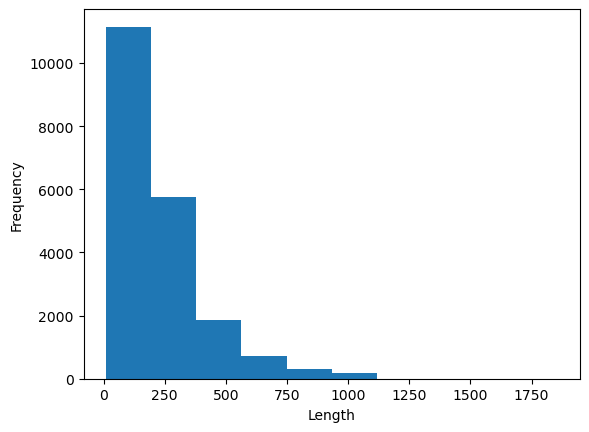

In [16]:
import matplotlib.pyplot as plt

plt.hist(   # hist : 빈도수
    trainLength
)
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

----
### Sequence Padding
 : 전체 자릿수를 100으로 가정했을 경우 한 문장에 토큰이 3개 있을 때 97개는 0으로 채움.    
    반면 한 문장에 토큰이 200개 있을 때 100개를 잘라버림.    
> Feature 갯수를 동일하게 하기 위한 작업

In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_seq = pad_sequences(train_input, maxlen=100)  # 숫자 늘어나면 오래걸림. 시간 상 100으로 해봄.
val_seq = pad_sequences(val_input, maxlen=100)

In [18]:
# 크기 확인
print(train_seq.shape, val_seq.shape)

(20000, 100) (5000, 100)


In [19]:
# 첫 번째 댓글 확인
print(train_seq[0])
# 맨 앞이 1이 나오는 게 맞으나, 여긴 아님. => 앞이 잘림
# 영어는 뒤에서부터 잘라 앞이 잘리는 게 맞음.

[ 10   4  20   9   2 364 352   5  45   6   2   2  33 269   8   2 142   2
   5   2  17  73  17 204   5   2  19  55   2   2  92  66 104  14  20  93
  76   2 151  33   4  58  12 188   2 151  12 215  69 224 142  73 237   6
   2   7   2   2 188   2 103  14  31  10  10 451   7   2   5   2  80  91
   2  30   2  34  14  20 151  50  26 131  49   2  84  46  50  37  80  79
   6   2  46   7  14  20  10  10 470 158]


In [20]:
print(train_seq[5])
# 1이 있고 그 앞에 0으로 채워진 걸로 보아 데이터 갯수가 100개가 안 되어 채워진 것.

[  0   0   0   0   1   2 195  19  49   2   2 190   4   2 352   2 183  10
  10  13  82  79   4   2  36  71 269   8   2  25  19  49   7   4   2   2
   2   2   2  10  10  48  25  40   2  11   2   2  40   2   2   5   4   2
   2  95  14 238  56 129   2  10  10  21   2  94 364 352   2   2  11 190
  24 484   2   7  94 205 405  10  10  87   2  34  49   2   7   2   2   2
   2   2 290   2  46  48  64  18   4   2]


---- 
#### 순환 신경망 모델 만들기

In [21]:
train_seq.shape

(20000, 100)

> 단어를 숫자로 바꾸는 과정에서 숫자는 우열로 가릴 우려가 있기 때문에 숫자를 우열로 보지 않고 그 자체로 보게 하기 위해서 **One-hot Encoding** 사용

In [22]:
# One-hot Encoding
from tensorflow import keras

train_oh = keras.utils.to_categorical(train_seq)
print(train_oh.shape)   # 맨 위에서 500개 단어만 쓰기로 했으므로 500개의 Feature 가 나옴.

(20000, 100, 500)


In [24]:
train_oh[1]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]], shape=(100, 500))

In [25]:
model = keras.Sequential()

model.add(
    keras.layers.SimpleRNN(
        8,
        input_shape=(100, 500)  # 위에 train_oh.shape 가 (20000, 100, 500) 이라서
    )
)

model.add(
    keras.layers.Dense(
        1,  # 긍정 / 부정 2개 있으므로
        activation='sigmoid'    # 둘 중에 판단하는 거
    )
)

c:\Users\tjoeun\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
# 검증 세트도 One-hot Encoding
val_oh = keras.utils.to_categorical(val_seq)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 8)              │         4,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Loss & Learning Rate
model.compile(
    optimizer = 'rmsprop',  # adam 은 단어에서 비추천
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [29]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_simplernn.keras")
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [30]:
history = model.fit(
    train_oh, train_target,
    epochs = 100,
    batch_size = 64,
    validation_data = (val_oh, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5196 - loss: 0.6922 - val_accuracy: 0.5258 - val_loss: 0.6902
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6172 - loss: 0.6618 - val_accuracy: 0.7388 - val_loss: 0.5987
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7485 - loss: 0.5403 - val_accuracy: 0.7582 - val_loss: 0.5011
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7863 - loss: 0.4700 - val_accuracy: 0.7536 - val_loss: 0.4999
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7968 - loss: 0.4443 - val_accuracy: 0.7776 - val_loss: 0.4713
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8030 - loss: 0.4328 - val_accuracy: 0.7548 - val_loss: 0.5097
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8062 - loss: 0.4243 - val_accuracy: 0.7666 - val_loss: 0.4850
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8116 - loss: 0.4197 -

> 전체 댓글의 토큰 중 100개만 학습하였더니 80% 이상의 예측력을 보였다.

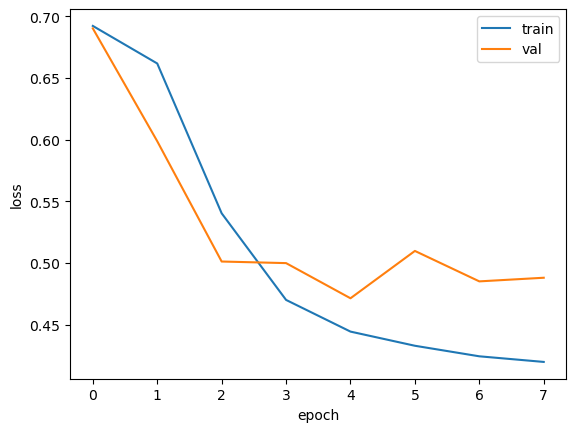

In [31]:
# 시각화 해보기
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

In [32]:
# 평가하기
model.evaluate(train_oh, train_target)

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8011 - loss: 0.4365


[0.436475545167923, 0.8010500073432922]

In [33]:
model.evaluate(val_oh, val_target)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7776 - loss: 0.4713


[0.4713323712348938, 0.7775999903678894]

----
### LSTM(Long Short Term Memory) - 요약해서 이전 거를 기억
- 컴퓨터는 요약을 명사 위주로 함

In [ ]:
model = keras.Sequential()
model.add(
    keras.layers.Embedding(500, 16)     # 숫자화 시키는 거, 단어가 몇 개 있는지
)
model.add(
    keras.layers.LSTM(8)
)
# 출력층
model.add(
    keras.layers.Dense(1, activation='sigmoid')
)

# 이게 차이점
model.build(
    input_shape=(None, 100) # 100 은 maxlength
)

In [37]:
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [39]:
checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_simplernn.keras") # 덮어씌웠음
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True
)

In [40]:
history = model.fit(
    train_seq, train_target,
    epochs = 100,
    batch_size = 64,
    validation_data = (val_seq, val_target),
    callbacks = [checkpoint_cb, early_stopping_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.6350 - loss: 0.6367 - val_accuracy: 0.6698 - val_loss: 0.5920
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7589 - loss: 0.5085 - val_accuracy: 0.6906 - val_loss: 0.6240
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7756 - loss: 0.4764 - val_accuracy: 0.7064 - val_loss: 0.5870
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7877 - loss: 0.4555 - val_accuracy: 0.7938 - val_loss: 0.4562
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7973 - loss: 0.4368 - val_accuracy: 0.6180 - val_loss: 0.7958
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8012 - loss: 0.4306 - val_accuracy: 0.7982 - val_loss: 0.4321
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8026 - loss: 0.4218 - val_accuracy: 0.7988 - val_loss: 0.4506
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8082 - loss: 0.4164 - 

In [41]:
# 평가하기
model.evaluate(train_seq, train_target)

625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8268 - loss: 0.3806


[0.3806314468383789, 0.8267999887466431]

In [42]:
model.evaluate(val_seq, val_target)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8046 - loss: 0.4221


[0.42208871245384216, 0.8046000003814697]

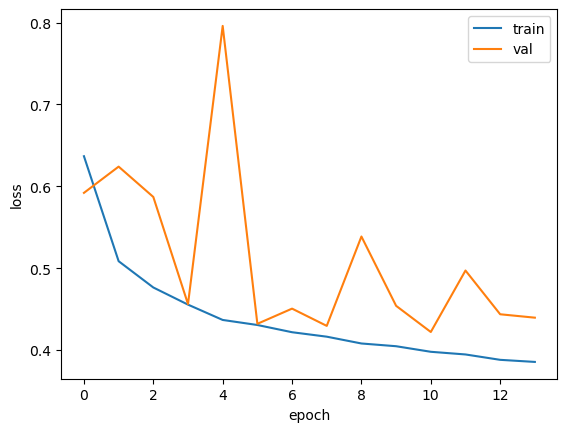

In [43]:
# 시각화 해보기
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()